# Model Pipeline

## Initial data and folder structure.

As stated in the [README.md](./README.md). file, it is important to ensure that the initial files are organized in a consistent structure.
The original training dataset `dynamic-rhythms-train-data`, provided by the contest, must be placed inside the raw data directory. Additionally, the meteorological data will be generated and stored by us in the same section. 

Here is the initial data expected folder structure (as seen from the root directory of the project):
```

dynamic-rythms/
│
├── data/
│   ├── external/                # Data from third-party sources.
│   ├── interim/                 # Intermediate data files.
│   └── raw/                     # Original, immutable data
│       ├── dynamic-rhythms-train-data/ # Provided by the contest
│       │   └── data/
│       │       ├── eaglei_data/
│       │       └── NOAA_StormEvents/
│       └── meteorological/      # API-generated storm condition data.
```


## Data Gathering.

To build a reliable dataset for storm-driven outage prediction, we implemented a multi-step data gathering processing strategy that integrates 
- outage reports
- storm episode records
- geospatial county data
- and hourly meteorological conditions

Our goal was to download and merge all the provided data focused exclusively on high-impact events, with clear storm-outage relationships and rich contextual information. The following sections outline each stage of the data preparation pipeline, from filtering relevant outages to generating API calls for weather data—forming the foundation of the predictive modeling framework.

![](../assets/images/initial-data-pipeline.png)

- a) **Outage Information**: We use the outage data. To ensure we focus on impactful events, we define a relevance threshold based on the number of people affected. Specifically, we only consider outages that impacted more than $10^{3.5}$, which corresponds to approximately $3162$ people. This allows us to filter out minor incidents and concentrate on events with significant societal impact. Additionally, we group nearby outage reports that occurred within a defined time frame and affected the same  neighboring counties. This allowed us to treat such cases as a single, prolonged event rather than multiple isolated incidents.

- b) **Storm Information**: We organized storm data at an *episode level*, grouping together related storm events that occurred within a single system. For each storm episode, we defined a start and end date to establish its duration. Recognizing that large storms can impact multiple counties simultaneously, we created a composite identifier by combining the storm episode ID with the county FIPS code. This new field, episode_fips_id, uniquely represents the intersection between a specific storm and a specific county, allowing us to track localized impacts of broader storm systems.

- c) **County Information**: We obtained official county boundaries from the U.S. Census Bureau using the  shapefile in this [link](https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_5m.zip). This shapefile provides precise geospatial data for all U.S. counties. We use this information to provide our meteorological API requests with accurate geographic points. 

- d) **Outage + Storm**: To associate outages with specific storm events, we merged storm and outage data based on temporal proximity. While we acknowledge this is a simplification, it provides a useful approximation for identifying likely storm-related outages. Specifically, we considered an outage to be linked to a storm if it occurred during the storm episode (covering case 1 and case 2) or within one day after its end (case 3). This rule allows us to flag storms that likely caused disruptions, and to distinguish them from those that passed without triggering significant outages. This cases are shown in the following figure:

![](../assets/images/outage_cases.png)

- e) **Defining the dataset scope**: At first instance, we narrowed our focus to include only storm episodes that were linked to at least one outage. This filtered set forms the foundation of our training dataset, ensuring that the model is initially trained on events with known impacts. By starting with confirmed storm-outage associations, we simplify the problem space and prioritize learning from patterns with clear outcomes, which will help refine and scale the model in future iterations (which are outside this scope).

- f-g) **API Calls**: We then generate a Dataframe containing information of the storms that resulted in at least one outage, merged with the county dataset. Since we have access to both storm and outage durations, we define a temporal window that spans from one day before to one day after each storm. This window allows us to later request hourly meteorological data relevant to each storm's lifecycle. To represent the geographic location of each county, we use its centroid coordinates (latitude and longitude), as pinpointing the exact affected city within a county is not always feasible. With the combination of the `episode_fips_id`, county centroid location and the defined date-time window, we are able to generate the corresponding API calls in batch, retrieving the meteorological conditions that potentially led to the observed outages. API calls are made with the [Power project](https://power.larc.nasa.gov/). The result of each API call is a JSON file containing detailed hourly meteorological conditions within the defined temporal window. Each JSON file is named using the corresponding episode_fips_id, enabling easy traceability and alignment with the original storm-outage pair. These files will later be parsed and transformed into structured features for the machine learning model.
-------------


### Meteorological Variables 

<div style="display: flex; align-items: center;">
  <img src="../assets/images/icons/METEOROLOGICAL_DATA.png" alt="Meteorological Data" style="width: 20%; max-width: 600px; height: auto;"/>

  <p>
    To enrich our dataset with real-world weather conditions surrounding each storm episode, we incorporated hourly meteorological data retrieved through the NASA POWER Project. The variables selected capture a wide range of atmospheric and environmental factors critical for understanding storm dynamics and their potential to cause outages. Importantly, all meteorological features retrieved are Near Real-Time (NRT) products, meaning they are updated frequently and available soon after the observations are made. This characteristic allows the project not only to model historical storm impacts but also to set the foundation for real-time model evaluation and deployment in production environments, enabling proactive outage prediction based on incoming meteorological conditions.
  </p>
</div>

The following table contains all the meteorological variables that were fetched through the API.

| Variable                | Description                                                                                      | Units               | NRT Available |
|--------------------------|--------------------------------------------------------------------------------------------------|---------------------|---------------|
| T10M                     | Average air (dry bulb) temperature at 10 meters above surface.                                   | °C                  | ✅             |
| ALLSKY_SFC_SW_DWN         | Total solar irradiance on a horizontal surface under all sky conditions.                        | Wh/m²               | ✅             |
| PS                       | Surface atmospheric pressure.                                                                  | kPa                 | ✅             |
| WS50M                    | Average wind speed at 50 meters above surface.                                                  | m/s                 | ✅             |
| ALLSKY_SFC_LW_DWN         | Downward thermal infrared irradiance under all sky conditions at the surface.                   | Wh/m²               | ✅             |
| WD50M                    | Average wind direction at 50 meters above surface.                                              | Degrees             | ✅             |
| PRECTOTCORR               | Bias-corrected total precipitation at surface.                                                  | mm/hour             | ✅             |
| GWETPROF                 | Soil moisture profile (surface to bedrock), 0 (dry) to 1 (saturated).                           | Fraction (0–1)      | ✅             |
| CLRSKY_SFC_SW_DWN         | Total solar irradiance on a horizontal surface under clear sky conditions.                     | Wh/m²               | ✅             |
| QV10M                    | Specific humidity at 10 meters (mass of water vapor per mass of air).                           | g/kg                | ✅             |
| RHOA                     | Surface air density.                                                                            | kg/m³               | ✅             |
| TO3                      | Total atmospheric ozone concentration from surface to top of atmosphere.                       | Dobson Units        | ✅             |
| TQV                      | Total column atmospheric water vapor content.                                                   | kg/m²               | ✅             |
| Z0M                      | Surface roughness length (height where mean wind speed becomes zero).                           | meters              | ✅             |
| TOA_SW_DWN               | Total solar irradiance at the top of the atmosphere.                                             | Wh/m²               | ✅             |
| RH2M                     | Relative humidity at 2 meters above surface.                                                    | %                   | ✅             |
| WS2M                     | Average wind speed at 2 meters above surface.                                                    | m/s                 | ✅             |
| CLRSKY_SFC_LW_DWN         | Downward thermal infrared irradiance under clear sky conditions at the surface.                 | Wh/m²               | ✅             |
| DISPH                    | Displacement height due to large obstacles (e.g., trees, buildings).                            | meters              | ✅             |



----
To execute the data gathering process, we need to run the following scripts:
- src/downloader.py
- src/cleaner.py
- src/storm_outages.py
- src/meteorological_api.py

When the scripts are run for the first time, the complete data gathering pipeline is executed. This includes downloading the necessary files, cleaning the data, merging storm and outage records, and retrieving meteorological information. Once the data has been successfully processed and stored, these steps are skipped in subsequent runs to avoid redundant computations.

In [1]:
import src.downloader as downloader
import src.cleaner as cleaner
import src.storm_outages as storm_outages
import src.meteorological_api as meteorological_api

In [2]:
%%time
downloader.download()

Info already exists...
Information is already saved at: /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/external/county.parquet
CPU times: user 3.6 ms, sys: 0 ns, total: 3.6 ms
Wall time: 25.1 ms


In [3]:
%%time
cleaner.execute()

Storm Events dataframe contains 2997 unofficial fips.
Assumption: These 2997 unofficial fips might be typos or mistakes.
After cleaning, Storm Events dataframe contains 979 unofficial fips.
Total amount of corrected fips: 2018
Saving Storm events cleaned dataframe at: /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/storm_events_cleaned.csv
It was possible a correction of about 67.33400066733401% of cases.
CPU times: user 35.8 s, sys: 2.76 s, total: 38.5 s
Wall time: 1min 42s


In [4]:
%%time
storm_outages.execute()

Reading file: /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/raw/dynamic-rhythms-train-data/data/eaglei_data/eaglei_outages_2014.csv.
Processing outages...
Deleting customers_out nulls...
Keeping relevant outages according to CUSTOMERS_OUT_NB=3162.2776601683795
Changing run_start_time to datetime...
Mapping state_ids...
Filling fips_code_ids...
Reading file: /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/raw/dynamic-rhythms-train-data/data/eaglei_data/eaglei_outages_2015.csv.
Processing outages...
Deleting customers_out nulls...
Keeping relevant outages according to CUSTOMERS_OUT_NB=3162.2776601683795
Changing run_start_time to datetime...
Mapping state_ids...
Filling fips_code_ids...
Reading file: /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/raw/dynamic-rhythms-train-data/data/eaglei_data/eaglei_outages_2016.csv.
Processing outages...
Deleting customers_out nulls...
Keeping relevant outages according to CUSTOMERS_O

In [11]:
%%time
meteorological_api.download_process()

API calls are turned off. If you know what you are doing, change the API_CALLS_ON parameter on the script. Otherwise, information might already be existing at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/external/meteorological
Checking if meteorological information is downloaded...
Attempting to download from uploaded file...
Getting info from https://huggingface.co/datasets/dhdzmota/dynamic-rythms-meteorological-information/resolve/main/meteorological.zip...
Done with extraction into /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/external.
CPU times: user 26.6 s, sys: 9.82 s, total: 36.4 s
Wall time: 2min 42s


## Dataset Handling

Once all the data has been gathered, we can begin constructing the foundational dataset for modeling. In this context, a storm is represented as a sequence of meteorological conditions over time. The central question the dataset is designed to answer is:
"Given the current weather conditions, will an outage occur in the next hour?"

To generate the response variable, we compare the timestamp of each meteorological observation with the recorded outage start times. Additionally, we engineer new features to better capture the underlying dynamics and patterns that may indicate an impending outage.



![](../assets/images/dataset-handling.png)

- a) **Storm and Outage Ingestion**: This step focuses on loading and filtering the previously computed outage and storm event data. Since duplicate entries may still be present, we perform an additional deduplication process. At this stage, we also reinforce our filtering criteria—retaining only impactful outages—and ensure that storm records are cleaned and grouped into well-defined episodes for consistent downstream processing.


- b) **Meteorological Data Ingesiton**: Meteorological data is loaded from a folder containing JSON files, each corresponding to a specific storm episode. These files cover a window, from one day before to one day after the storm. And are generated using the centroid coordinates of each affected county to ensure geographic consistency.


- c) **Merging and Processing**: In this step, we merge the cleaned outage, storm, and meteorological datasets to create a unified base dataset, aligned both temporally and geographically. The data is organized at an hourly granularity, but for modeling purposes, we retain only from the three hours leading up to the start of each storm episode until the outage generation. We compute a feature called time_to_outage, which represents the time difference between each weather observation and the start of the associated outage. This allows us to construct the response variable for our model: `"Given the current weather conditions, will an outage occur within the next hour?"`


- d) **Initial Base Dataset** The merged dataset is stored in Parquet format to enable efficient access, compression, and scalability. At this stage, the dataset contains the core aligned features—outage, storm, and meteorological data—prior to any additional feature engineering.


- e) **Feature engineering**: New features are engineered to enhance the model’s ability to detect outage signals by capturing temporal dynamics and weather behavior patterns. We generate a variety of lag-based, delta, and trend features from the meteorological time series data. Specifically:
    - Difference features are computed, such as the temperature gap between 10m and 2m heights, and wind speed differences between 50m and 2m, capturing vertical variation in atmospheric conditions.
    - For each weather variable, we calculate its value at previous time steps (1, 2, and 3 hours ago) to provide temporal context.
    - Using these lags, we compute delta features to measure how conditions change over time, both from the current hour to previous hours and between earlier steps (e.g., change from 1h to 2h ago).
    - Finally, we derive tendency indicators to capture the directional trend (increasing, decreasing, or stable) in the weather variables over time.

This comprehensive feature set allows the model to learn from not only the current state of the weather, but also how it has evolved leading up to a potential outage.

- f) **Final Processed Dataset**: After applying all transformations and feature engineering steps, the final version of the dataset is saved in Parquet format. This version is fully prepared for machine learning, containing both the engineered features and the target variable that indicates whether an outage will occur within the next hour.


- g) **Dataset Splitting**:
The final dataset is divided into multiple subsets, each serving a distinct purpose within the modeling pipeline:

    - Train: Used to fit the machine learning model.

    - Test: used during development to evaluate performance and prevent overfitting.

    - Eval: Reserved for model comparison, tuning, and selection.

    - OOT (Out-of-Time): A temporal holdout set to simulate performance on unseen, future data.

    - Cal (Calibration): Used specifically for calibrating prediction intervals in conformal prediction.

In [12]:
import src.data_dataset_creation as data_dataset_creation
import src.dataset_splitting as dataset_splitting
import src.feature_generation as feature_generation

### Dataset creation

In [13]:
%%time
data_dataset_creation.execute()

Generating Storm-outage data with meteorological information.
Processing storm-outage data...
Processing meteorological jsons data...
Done with process...
Saving data at: /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/meteorological_data_with_outages.parquet
CPU times: user 15min 32s, sys: 8.33 s, total: 15min 40s
Wall time: 24min 24s


### Feature engineering

In [16]:
%%time
feature_generation.compute_features()

Reading /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/meteorological_data_with_outages.parquet file
Computing the features...
Done.
Saving feature data at: /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/outage_features.parquet
CPU times: user 39.6 s, sys: 11.6 s, total: 51.2 s
Wall time: 1min 16s


### Dataset splitting

The full dataset, from time $T_{0}$ to $T_{f}$, is split as follows:

- Train Window: 80% of the total timeline, used to develop the model.
- OOT Window: 15% of the timeline, held out entirely for out-of-time evaluation. This will generate the `oot` set, which is used as a strict temporal holdout, simulating future data and providing an unbiased view of how the model might perform in real-world, unseen scenarios.
- Buffer: A 5% buffer is skipped between Train and OOT windows to prevent data leakage.
  

Within the Train Window, the data is first split into:
- `train`: 80%, this will be a transitory train set. 
- `test`: 20%, this split supports development and internal validation during model training.

The `train` set is further divided into:
`train`: 80%, used to fit the model
`trans`: 20% – Used only as a transitivity file, which will be converted into `eval` and `cal`.

The `trans` subset is then split equally into:
- `eval`: 50% – Used for model selection and hyperparameter tuning.
- `cal`: 50% – Used for conformal prediction calibration, ensuring well-calibrated uncertainty estimates.

![](../assets/images/data-split.png)







In [17]:
%%time
dataset_splitting.splitting_process()

Reading /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/outage_features.parquet file
Getting train and OOT windows...
Train window data has 80.0% of data.
OOT window data has 15.0% of data.
We are discarding 4.9999999999999964% of data.
Done.
Splitting datasets
Getting test dataset...
Getting train dataset...
Getting cal and eval datasets...
Done.
Datasets relative percentages:
    train: 53.86926795279362%
    test: 16.835779297130166%
    cal: 6.732569786177764%
    eval: 6.73692461786352%
    oot: 15.825458346034926%
Saving train data into the path /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/train.parquet
Saving test data into the path /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/test.parquet
Saving cal data into the path /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/cal.parquet
Saving eval data into the path /mnt/c/Users/52333/Documents/projects/test/dyna

## Modeling

The modeling pipeline leverages all predefined dataset splits, each serving a distinct and essential role in building a robust predictive system. From initial model training and hyperparameter modification, to comprehensive performance evaluation and uncertainty quantification, each stage contributes to refining the model’s reliability and real-world readiness. This structured approach ensures not only strong predictive power, but also interpretability and confidence in the results.

![](../assets/images/model-pipeline.png)

- a) **Model Training with XGBoost**: The training process begins with the `train` split of the dataset, which is used to fit an XGBoost classifier. XGBoost was selected due to its proven effectiveness in handling the specific characteristics of this problem. In particular:
    - It excels at working with tabular data, where each feature (column) represents a distinct concept — a common structure in our meteorological dataset.
    - It handles high-cardinality and non-linear relationships effectively, which is essential for modeling the complex interactions in storm-related weather patterns.
    - It offers efficient training on large datasets and includes built-in regularization, helping to prevent overfitting.
    - Additionally, XGBoost integrates seamlessly with SHAP (SHapley Additive exPlanations), allowing for detailed interpretability, a key requirement for understanding and justifying predictions in high-stakes operational contexts.


- b) **Parameter modification**: The `eval` dataset is reserved for hyperparameter modification, specifically to prevent overfitting during training through the `early_stopping_rounds` parameter. Its primary function is to provide real-time evaluation feedback while the model is being trained, stopping the training process when performance on the `eval` set stops improving, effectively limiting the number of trees in the ensemble. By using this dataset, we ensure that model adjustments are guided by data not seen during training, thereby enhancing generalization performance. Importantly, this validation process relies on threshold-independent metrics to objectively assess model quality without depending on arbitrary classification thresholds.

- c-d-e) **Model Evaluation and Explanation**: After training, the model is evaluated using the `test` and `oot` datasets. Threshold-independent metrics are prioritized, including `AUC-ROC`, `AUC-PR`, and `Brier Score`, computed through robust methods like bootstrapping, to generate a reliable confidence interval for each metric. Additionally, explainability is incorporated using SHAP (SHapley Additive exPlanations) values to analyze feature contributions. This dual focus ensures we understand not only how well the model performs statistically, but also why it makes specific predictions, both critical aspects for operational reliability and trust.


- f) **Uncertainty quantification**: The `cal` dataset is used to train a conformal prediction model via the MAPIE library. MAPIE wraps the trained classifier, allowing us to quantify uncertainty by providing prediction sets at a controlled error rate (alpha), defining a score area where modeling might not be certain at all. This calibration step guarantees that the model’s score intervals are statistically valid, offering trustworthy risk assessments critical for decision-making under uncertainty.


- g) **Robust model**: The final output is a robust model capable of making accurate and uncertainty-aware predictions. By integrating high-performing predictions, calibrated uncertainty quantification, and SHAP-based interpretability, the system is positioned not only to predict outages reliably but also to communicate the confidence behind each prediction, which is a vital capability for real-time, high-stakes applications.
 

In [18]:
import src.training_model as training_model
import src.understanding_model as understanding_model
import src.conformal_predictions as conformal_predictions

### Training 

The training process is managed through the `training_model` python script using the `train_model` function, ensuring a systematic and reliable approach to model development. It integrates dataset handling, class imbalance correction, model fitting, performance scoring, and optional saving of intermediate artifacts for downstream tasks.


Key aspects of the training strategy include:

- Class imbalance handling: Given the rarity of outage events, the scale_pos_weight parameter is dynamically adjusted. This ensures that XGBoost assigns appropriate importance to the minority class during training.

- Early stopping: The model leverages early stopping on the evaluation set to prevent overfitting, improving its ability to generalize to unseen data.

- Artifact saving: After training, the model and prediction scores across different dataset splits are saved, enabling efficient evaluation, interpretation, and future pipeline steps without retraining.

This modular and cautious design ensures the training phase is efficient, reproducible, and ready for deployment.

In [19]:
model = training_model.train_model(save_data=True)

Reading data for train at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/train.parquet.
Reading data for test at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/test.parquet.
Reading data for eval at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/eval.parquet.
Reading data for cal at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/cal.parquet.
Reading data for OOT at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/interim/OOT.parquet.
 The model parameters are: {'n_estimators': 1000000, 'learning_rate': 0.1, 'max_depth': 3, 'scale_pos_weight': np.float64(29.40860841423948), 'use_label_encoder': False, 'eval_metric': 'aucpr', 'reg_lambda': 1, 'alpha': 1, 'subsample': 0.75, 'colsample_bytree': 0.75, 'early_stopping_rounds': 25, 'gamma': 1, 'seed': 42}
Start with training...
[0]	validation_0-aucpr:0.11995	validation_1-aucpr:0.12664
[1]	validation_

### Evaluation

After training, the model undergoes a comprehensive evaluation across multiple data splits, including train, test, out-of-time (OOT), evaluation (eval), and calibration (cal) datasets.

This evaluation focuses on threshold-independent metrics, particularly AUC-ROC, to objectively assess the model’s ranking ability without being biased by specific decision thresholds.

By analyzing performance across different splits, we aim to verify not only the model’s predictive strength but also its ability to generalize to unseen and future data, a critical requirement for real-world deployment.

In [21]:
x, info = understanding_model.get_final_datasets()
aucpr_baseline = info['train'].y.mean()

In [22]:
metrics = understanding_model.generate_general_metrics(info)

Saving info at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/temp_results/general_metrics.parquet


#### General AUCROC

- High performance across all splits:
All datasets achieve an AUCROC near or above 0.88, indicating the model's strong ability to distinguish between outage and non-outage events.

- Minimal overfitting:
While the training set reaches a slightly higher AUCROC (0.92), the evaluation (eval), testing (test), out-of-time (OOT), and calibration (cal) sets maintain very close and consistent scores around 0.88–0.89.
This suggests that overfitting is minimal, and the model generalizes well to unseen data.

- Stability in temporal extrapolation:
The OOT dataset — which simulates future, unseen conditions — achieves an AUCROC of 0.889, nearly identical to the evaluation set.
This indicates temporal stability: the model is not overly reliant on specific time periods and can perform reliably in prospective deployments.

- Calibration readiness:
The calibration set (cal) also scores highly (0.881), suggesting that the model is well-prepared for the uncertainty quantification step, with a strong base probability ranking even before calibration adjustments.

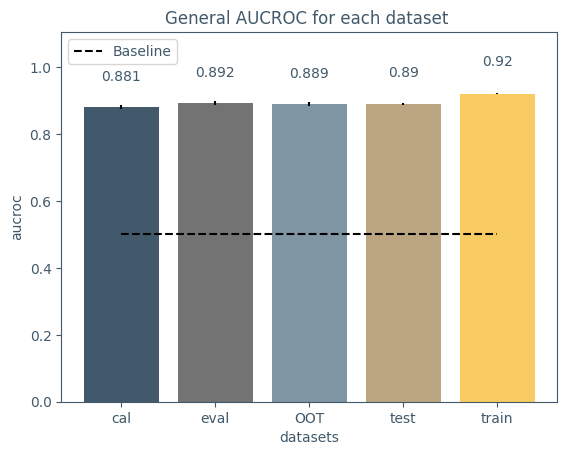

In [23]:
m = understanding_model.plot_general_metrics(metrics, 'aucroc', baseline=0.5)

#### General AUCPR

- Significant improvement over random:
The baseline (random) AUCPR is very low (approximately aligned with the positive class prevalence, likely around ~0.03–0.04).
The model consistently achieves AUCPR values 8 to 10 times higher than random guessing across all splits.

- Good generalization with slight drop OOT:
The OOT dataset, representing future unseen data, scores slightly lower (0.267) than the evaluation (0.309) and test (0.294) datasets.
This drop is expected in real-world deployments, but remains moderate, suggesting the model retains strong predictive power beyond the original training period.

- Stable performance across evaluation splits:
The cal, eval, and test splits show very consistent AUCPR scores (~0.27–0.30), indicating reliable model behavior across different data partitions.

- Moderate overfitting:
The train AUCPR is 0.343, somewhat higher than the others (~0.05–0.08 points).
While some overfitting is present, it is not extreme, and the generalization gap remains acceptable for operational settings.



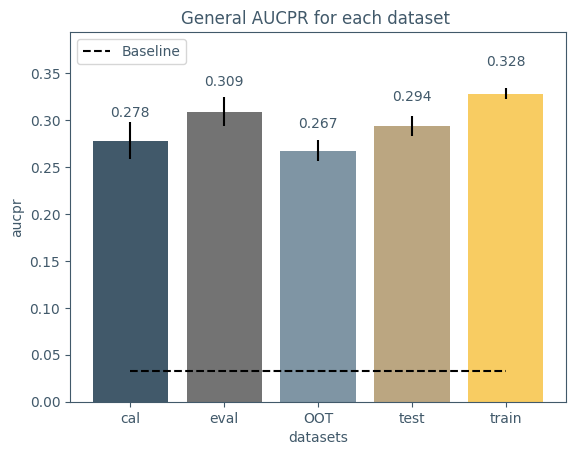

In [36]:
m = understanding_model.plot_general_metrics(metrics, 'aucpr', baseline=aucpr_baseline)

#### General Brier Scores

- Low Brier Scores overall:
All splits achieve Brier Scores below 0.14, which indicates that the model’s probability estimates are generally well-calibrated and not overconfident.

- OOT performance is even better:
The OOT set (future unseen data) achieves the lowest Brier Score (0.098), meaning the model's probability predictions are reliable when extrapolated to future conditions.

- Consistent calibration across datasets:
The calibration (cal), evaluation (eval), and testing (test) datasets show very similar Brier Scores (~0.12).
This suggests that there is no significant degradation in the quality of probability predictions across different splits.

- Minimal overfitting:
The train set has a slightly lower Brier Score (0.119), but the difference with evaluation and testing sets is small (~0.003–0.005 points), indicating very controlled overfitting in probability calibration.

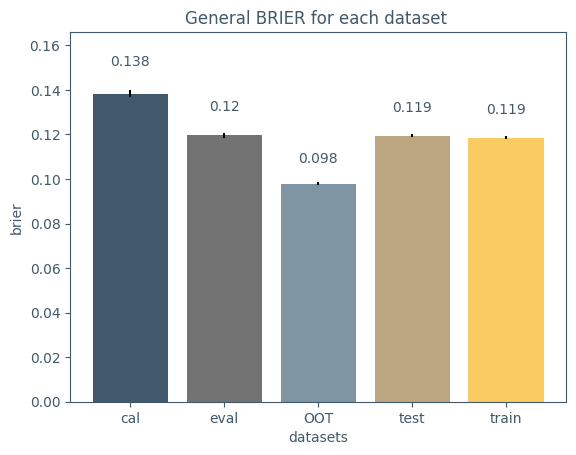

In [25]:
m = understanding_model.plot_general_metrics(metrics, 'brier', baseline=None)

In [26]:
grouped_info_metrics = understanding_model.generate_grouped_info_metrics(info, months=6)

Saving info at /mnt/c/Users/52333/Documents/projects/test/dynamic-rythms/src/../data/temp_results/grouped_info_metrics.parquet


---
While global evaluation metrics such as AUCROC, AUCPR, and Brier Score provide valuable insights into model performance, they alone are not sufficient to fully validate the model's robustness.
In real-world applications — particularly those affected by seasonal weather patterns and changing environmental conditions — it is critical to assess how model performance evolves over time.
By incorporating a temporal evaluation, we ensure the model remains reliable not just on historical data, but also under shifting conditions that could impact future predictive accuracy.



#### AUCROC over time
We tracked the model’s AUCROC performance across different datasets (train, test, and OOT) over time, grouped by 6-month periods.


- Consistently strong train and test performance:
From 2015 through 2022, the model maintains stable and high AUCROC values for both training and testing datasets.

    - Train scores remain tightly clustered between 0.90 and 0.94, showing the model consistently ranks positives highly.

    - Test scores are slightly lower (~0.86–0.91) but remain robust, suggesting strong generalization to unseen historical data.

- OOT performance is initially strong, slight decline in 2022:
The OOT dataset (future data) shows good stability through early extrapolations but exhibits a small downward trend starting in 2023.
Recent periods (2023-2024) show OOT AUCROC dropping towards 0.88.

- Possible distribution shift over time:
The decline in OOT AUCROC suggests there might be gradual changes in storm patterns, reporting practices, or other external factors starting around 2023, leading to slightly more difficult prediction conditions.

- General robustness despite time evolution:
Even with slight degradation, OOT AUCROC remains significantly above the baseline (~0.5), indicating that the model retains useful predictive power even under changing conditions. And comparisons between previous dates seems to be between the normal range of usual scores. 




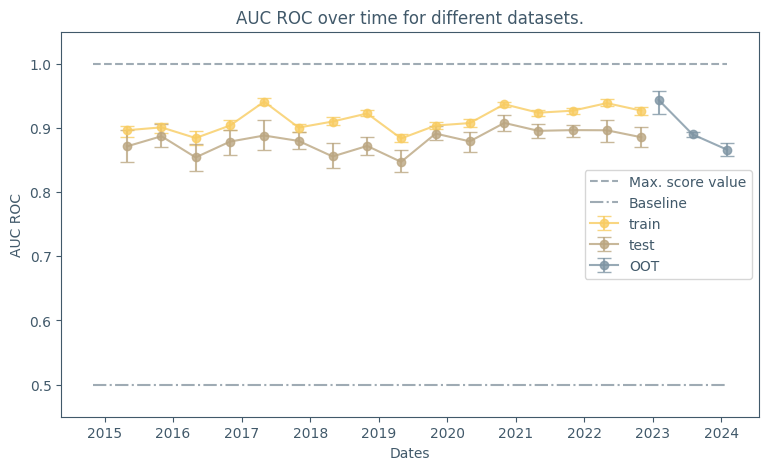

In [31]:
understanding_model.plotting__auc_roc(grouped_info_metrics)

#### AUCPR over time

- Stable AUCPR on historical data:
Both train and test datasets show relatively consistent AUCPR scores from 2015 to 2023, fluctuating within expected margins:

    - Train AUCPR generally stays higher (~0.30–0.40).

    - Test AUCPR follows a similar but slightly lower trend (~0.25–0.35). These fluctuations are normal in real-world settings where meteorological variability affects outage predictability.

- Pronounced OOT deterioration after 2022:
In the OOT dataset, AUCPR drops sharply just after 2022, falling to just about 0.2 by 2024.
This suggests the model struggles more with precision and recall when predicting future events under new, possibly shifted, environmental conditions.

- Precision-Recall degradation is sharper than ROC:
Compared to AUCROC trends, the AUCPR decline is much more significant.
Since AUCPR is more sensitive to class imbalance and false positives, this highlights that real-world deployment could face challenges in correctly identifying true outage events without an increase in false alarms if the model is not updated.

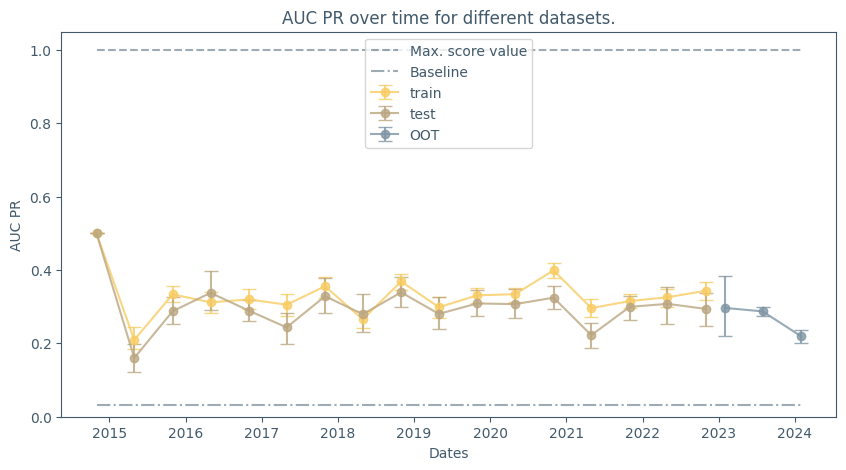

In [28]:
understanding_model.plotting__auc_pr(grouped_info_metrics, baseline=aucpr_baseline)

#### Brier Scores over time
- Fluctuations in early periods (2015–2019):
Both train and test datasets show relatively higher Brier scores (around 0.15–0.20) in earlier years, reflecting less calibrated predictions in the earlier periods of the data.
This can be attributed to natural variability or differences in early storm reporting and outage behavior.

- Noticeable calibration improvement after 2020:
Starting around 2020, Brier scores decrease significantly, falling closer to 0.10–0.12, which signals a marked improvement in probability calibration over time.

- OOT behavior mirrors general trends:
In the OOT period, Brier scores are fairly low (~0.075–0.135), especially in 2023 and early 2024, although there’s a slight spike.
This suggests that even though AUCPR performance decreased in OOT, the raw probabilities remain reasonably calibrated, an important factor for uncertainty estimation.

- Calibration robustness across datasets:
Despite slight variations, train and test splits move consistently together, indicating no significant calibration drift between training and evaluation conditions.

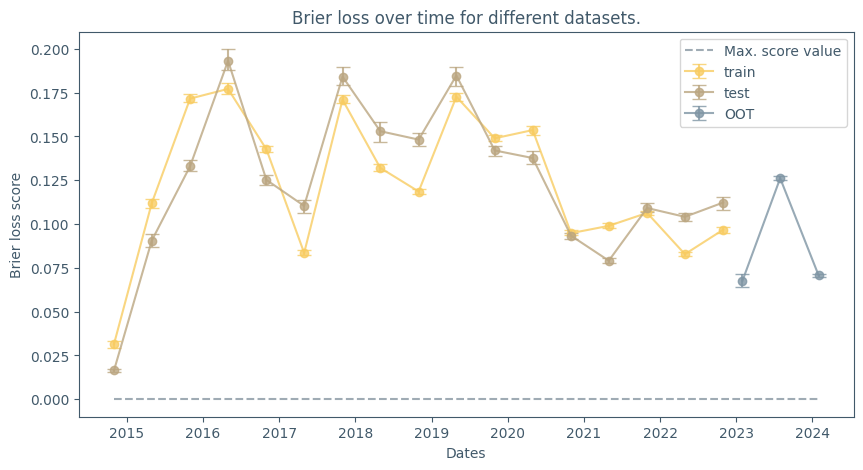

In [29]:
understanding_model.plotting__brier_loss_score(grouped_info_metrics)

---
Beyond achieving strong overall scores, an important measure of a model’s quality is its ability to faithfully represent real-world dynamics.

In the context of outage prediction, we expect that as an event approaches, the likelihood of occurrence should naturally increase.

Therefore, a reliable model should not only perform well on aggregate metrics but also mirror the true behavior of outage in different conditions.

We explore this behavior by analyzing how the model’s average predicted score changes as a function of the number of hours remaining before an outage occurs.

- High predictive scores close to outage events:
When there are few hours left (0–3 hours) before an outage, the model assigns higher probabilities, with average scores around 0.7–0.8 in train and slightly lower (~0.65–0.7) in OOT.
This indicates the model effectively detects the proximity of an outage event, as expected.

- Gradual decline as the outage becomes more distant:
As the number of hours before the outage increases, the average score smoothly declines for both datasets, reaching around 0.2–0.3 by 36 hours.
This behavior shows that the model captures the intuition that some meteorological conditions are equivalent to a "farther away" event, yielding a lower risk (score in this case).

- Good generalization across temporal windows:
Although OOT scores are slightly lower, the pattern remains consistent with the train set.
This suggests that even when moving into future, unseen data, the model's understanding of temporal risk dynamics is preserved.

- Minimal bias between training and future data:
The small offset between train and OOT curves implies moderate domain shift, but not a catastrophic failure in predictive behavior across time horizons.


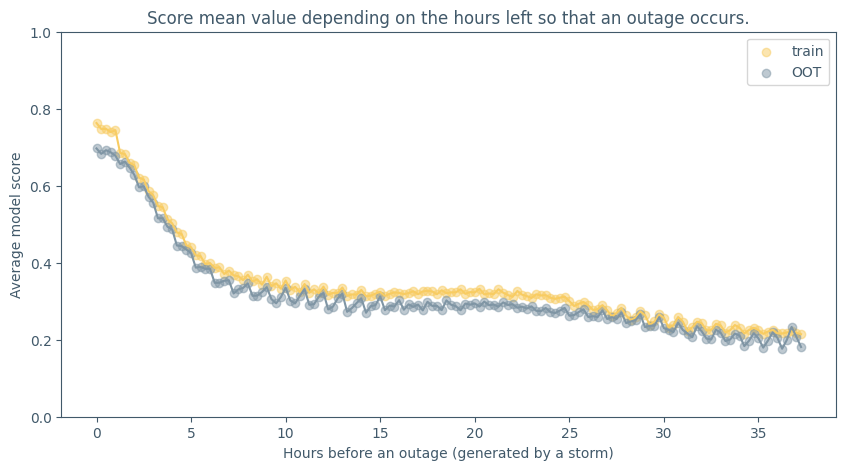

In [30]:
understanding_model.plotting_score_hours_before_outage(info)

---
After a comprehensive evaluation across multiple metrics and perspectives, three key takeaways emerge regarding the model’s performance:

1. Strong and Consistent Predictive Ability Across Datasets
2. Reliable Probability Estimates
3. Temporal Robustness with Early Signals of Distribution Shift



### Explanation

While predictive performance is essential, understanding how the model makes its decisions is equally important.

To achieve this, we use SHAP values (SHapley Additive exPlanations), a method grounded in cooperative game theory that provides individual and global feature attributions.By analyzing SHAP values, we can identify the most influential meteorological and contextual variables driving the model’s predictions, gaining deeper insights into the underlying factors associated with the target prediction.

------
#### General SHAP summary plots:

SHAP summary plot illustrate the impact of each feature on the model’s predictions across the test set:

- X-axis: SHAP value, the effect of the feature on increasing (positive SHAP value) or decreasing (negative SHAP value) the model’s output.
- Each dot: A single prediction instance for a given feature.
- Color gradient: Feature value for that instance (blue = low value, pink = high value).

Features at the top are the most influential across the dataset, while those toward the bottom have lesser overall impact.

The spread of the dots shows how much variability in impact a feature can have depending on its value.


-----
##### TEST set SHAP summary plot:

- Geographic location is highly predictive:
`coord0` and `coord1` corresponding to latitude and longitude appear among the top features, suggesting that the location of the storm significantly affects the likelihood of an outage. In other words, some geographic regions are evidently more vulnerable than others.

- Recent precipitation intensity is critical:
Several lagged precipitation features — `PRECTOTCORR_6_hours_ago`, `7_hours_ago`, `8_hours_ago`, `9_hours_ago`, and `10_hours_ago` — dominate the top rankings. This highlights that heavy precipitation in the hours leading up to the event is strongly associated with a possible outage generation.

- Time-related features also matter: `day_of_year` (seasonality) and `day_of_week` have a non-negligible impact, suggesting that temporal factors (like storm seasonality or weekday vs weekend) influence outage risk. This may capture underlying seasonal weather patterns.

- Wind speed and solar radiation variations are important factors as well: Features like `WS50M_6_hours_ago`, `WS50M_7_hours_ago` (wind speed), and `WD50M` (wind direction) show moderate importance. Solar radiation metrics (`ALLSKY_SFC_LW_DWN_5_hours_ago`) also appear, possibly reflecting storm severity (e.g., low solar radiation due to heavy clouds).






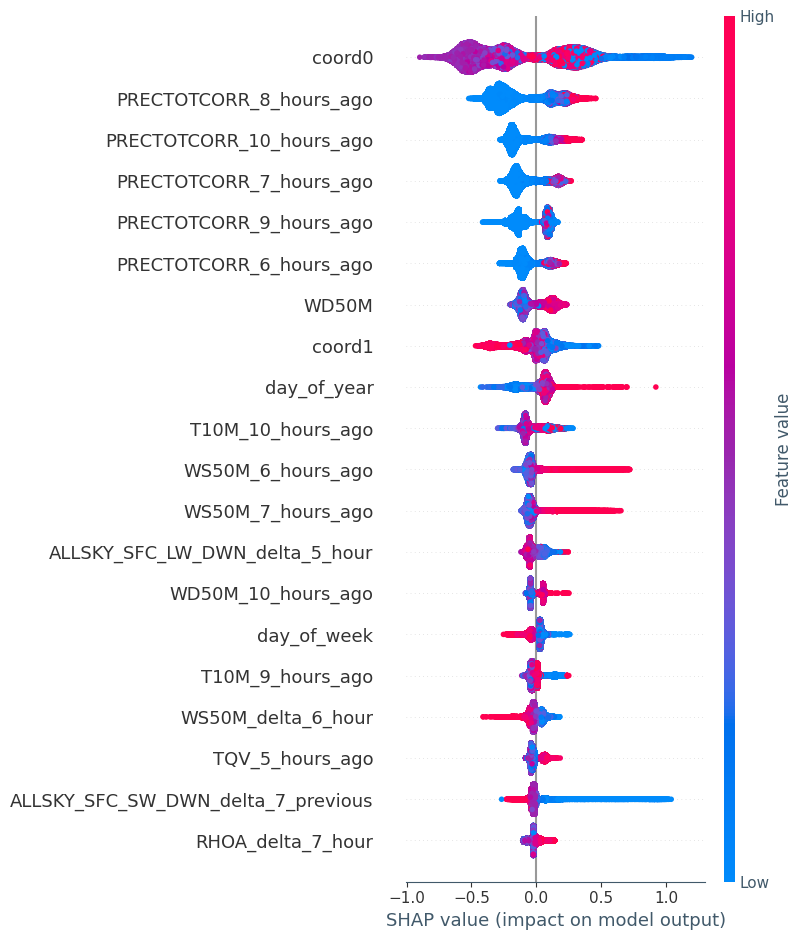

In [32]:
understanding_model.general_shap_summary(x, sets=['test'])

##### OOT set SHAP summary plot:

- Geographic dependency remains strong:
`coord0` is again the most influential feature, confirming that location continues to play a critical role in predicting outage risk even as conditions change over time. `coord1` appears as well in the top features.

- Precipitation features remain dominant:
Features related to precipitation (`PRECTOTCORR` at multiple lag hours) consistently rank at the top, confirming that recent heavy precipitation is still a major indicator of outages.

- Temporal features are still relevant:
`day_of_year` and `day_of_week` continue to appear among important features, suggesting that seasonality and weekly patterns remain predictive even in new unseen data.

- Solar radiation and wind continue to be moderate indicators:
Variables like `ALLSKY_SFC_SW_DWN_6_hours_ago`, `WD50M`, and `WS50M_6_hours_ago` maintain influence, although their contribution is smaller compared to precipitation and location.

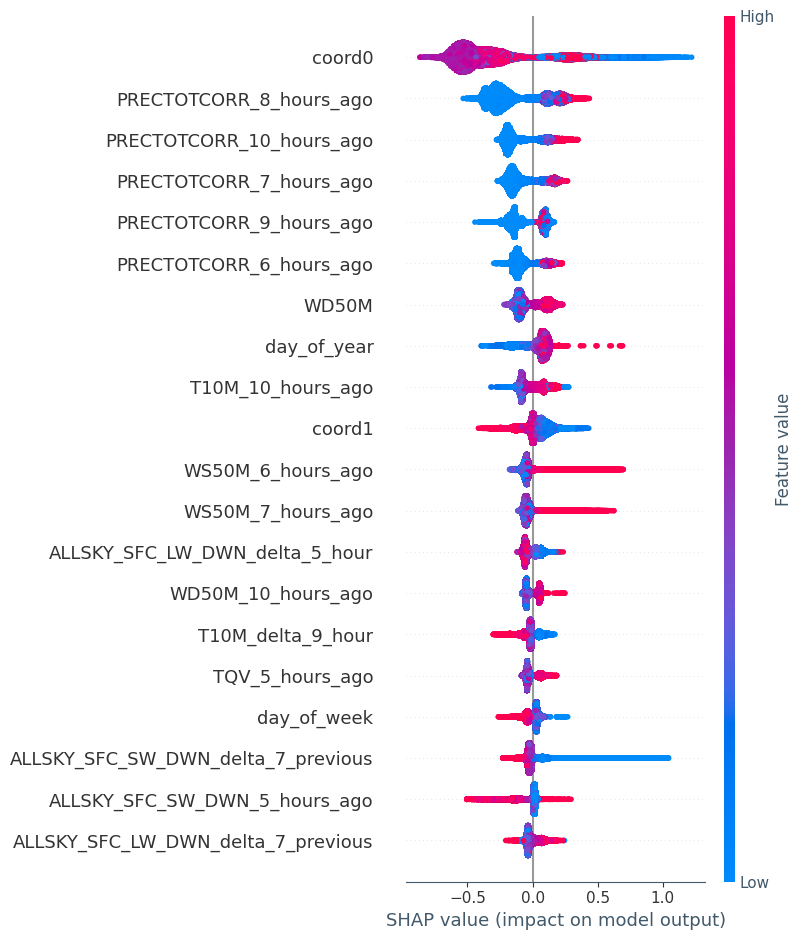

In [33]:
understanding_model.general_shap_summary(x, sets=['OOT'])

#### Single storm analysis

In this analysis, we observe a single storm event evolving over time.
Each point on the dark line represents the model’s forecast at a particular hour, based on the observed meteorological conditions up to that point. 

 The colored stacked area beneath the line shows normalized feature importance at each time step, helping to interpret what drives the model’s confidence at different stages of the storm.
 
An analysis can be done in the Early Phase and the Late phase.

- Early Phase: the beginning of the timeline, the most influential features are related to precipitation, specifically `PRECTOTCORR_8_hours_ago`, `PRECTOTCORR_10_hours_ago`, and `PRECTOTCORR_7_hours_ago`. These variables are among the top contributors despite holding a value of 0, indicating that no precipitation was present during those time frames. This suggests that the model is sensitive to the absence of early warning signs. Additionally, `coord1` emerges as a key factor, highlighting that regional vulnerability (such as geographic susceptibility) is already playing a role in shaping the model’s low-risk prediction.
- Middle Phase: As the storm develops, the model begins to detect more indicative signals. The prediction score increases significantly — rising from approximately 0.1 to nearly 0.9, reflecting a shift from low to high confidence in the likelihood of an outage. This transition marks a crucial turning point where meteorological signals likely intensify and compound.
- Late Phase: Toward the end of the timeline, the most influential features remain centered around precipitation, specifically `PRECTOTCORR_8_hours_ago`, `PRECTOTCORR_10_hours_ago`, `PRECTOTCORR_6_hours_ago`, and `PRECTOTCORR_7_hours_ago`. Unlike in the early phase, these variables now hold positive values, indicating that active and ongoing precipitation is present at this stage. This shift reflects the model's ability to respond to worsening meteorological conditions. Additionally, geographical features, such as `coord1` and `coord0`, continue to play a significant role, reinforcing the influence of regional vulnerability in determining outage risk as the storm intensifies.


**Conclusion**: The comparison between the early and late phases reveals the model’s capacity to adapt its reasoning as a storm evolves:
- In the early phase, the model assigns high importance to precipitation-related features even when their values are zero, showing it has learned that the absence of early precipitation is still informative — possibly as a baseline or contrast for future escalation.
- In the late phase, the same features now carry positive precipitation values, reflecting active weather conditions, which the model interprets as strong indicators of impending outages.

Throughout both phases, geographic coordinates (coord1, coord0) consistently influence the prediction, underscoring the model’s recognition that location-specific vulnerability is a persistent and context-independent factor.

---

We also made a plot of a SHAP decision plot. For the same storm.
This plot shows how the model’s prediction is built progressively for each moment during the life of a storm, starting from the least important feature and accumulating effects upward. Each line represents the prediction evolution for a specific hour during the storm.

- Solid blue/purple lines: Instances where no outage occurred (target = 0).
- Dashed red lines: Instances where an outage did occur (target = 1).
- Features are ordered from least important (bottom) to most important (top).
- As you move up, features contribute increasingly larger shifts in the model’s decision.

To read this graph, 
Predictions start low on the plot (bottom features), and build up progressively as more important features are considered.
The final decision (final model output value) is strongly influenced by the top most features, but the interesting thing is that contributions by each  feature drive the decision into a given score. 

We can analyze how precipitation features influence the model’s decision-making over time. For example, in the early predictions, the feature `PRECTOTCORR_8_hours_ago` shows a leftward slope, indicating a negative contribution to the model score when no precipitation is present. As the storm progresses and precipitation begins, this slope shifts to the right, reflecting a positive contribution toward predicting an outage. A similar pattern is observed in `PRECTOTCORR_7_hours_ago`, though the effect is lagged by one hour, consistent with the feature’s time offset. This behavior is consistent across multiple precipitation-related features, highlighting their temporal alignment and increasing influence as conditions worsen.

In terms of geographic features, `coord0` generally contributes negatively to the model output, while `coord1` tends to have a positive impact, suggesting that regional vulnerability patterns differ significantly based on location and are factored into the model’s scoring logic.

This decision plot demonstrates how the model builds confidence hour by hour, gradually shifting its prediction upward when severe weather patterns emerge. It captures not only which features matter most, but also when they start tipping the prediction toward an outage.

The distinction between dashed red (outage) and solid blue/purple (non-outage) trajectories reflects a well-calibrated and interpretable rare-event classifier.

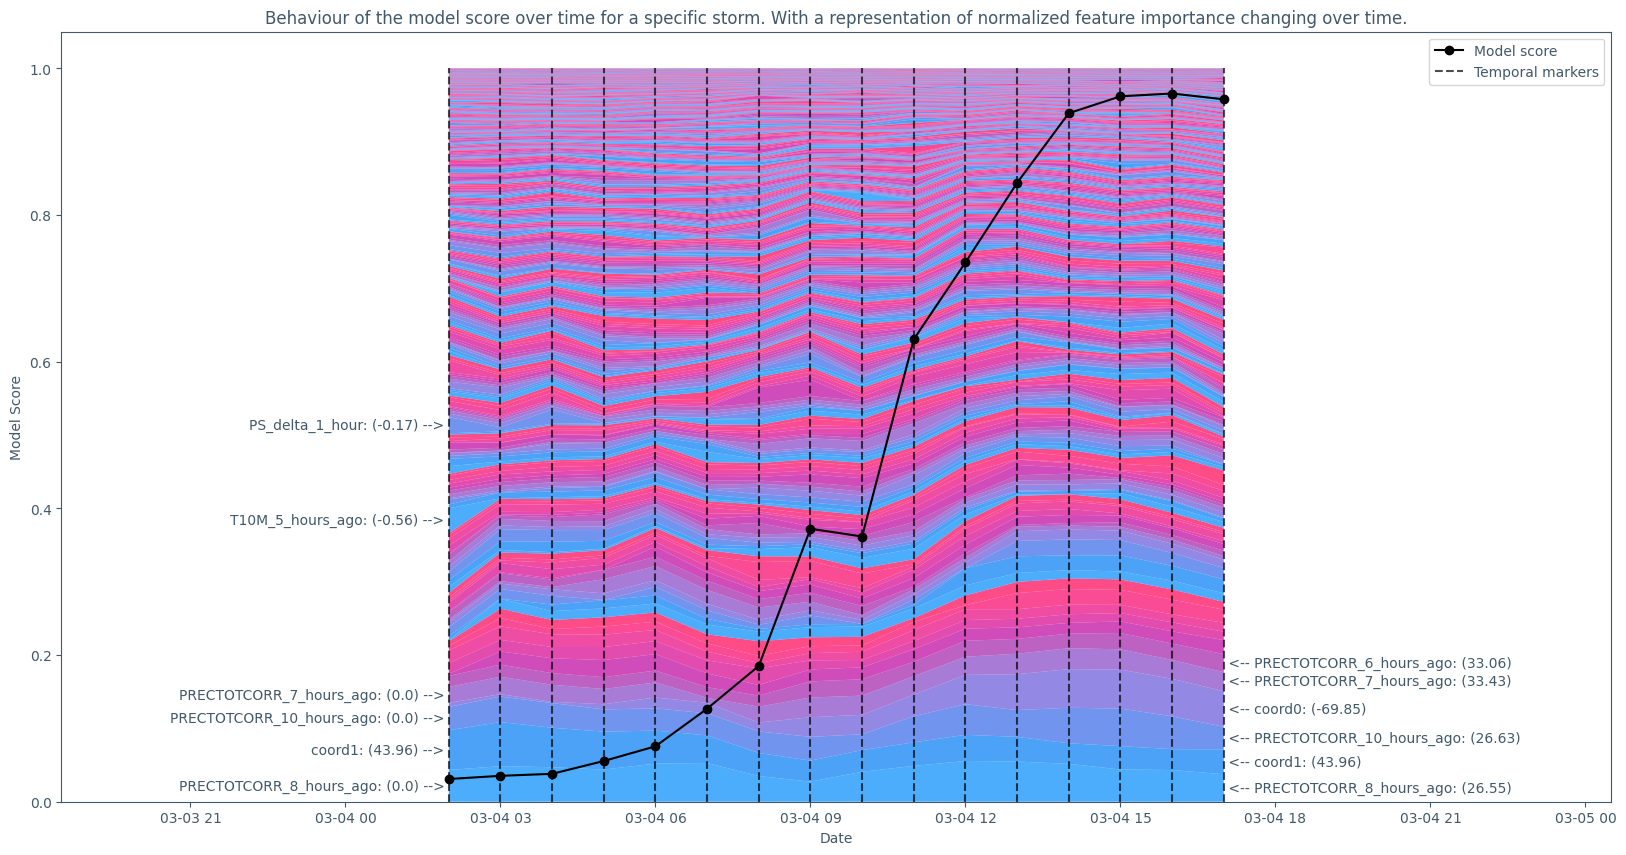

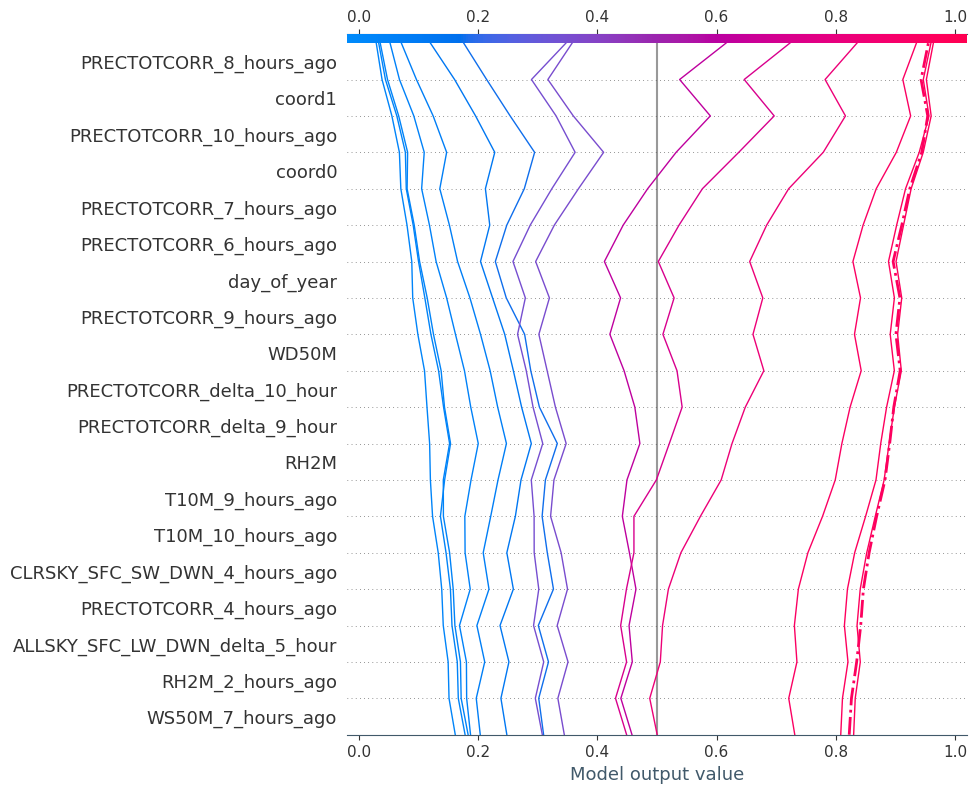

In [34]:
understanding_model.shap_importance_for_each_sample(x, info)

### Uncertainty quantification

In traditional classification, a single probability score is produced, but it can be challenging to know how confident the model truly is about its output.

Conformal prediction offers a principled framework to address this: by calibrating the model outputs, it enables the estimation of prediction uncertainty with statistical guarantees.

Instead of only making a binary decision, conformal prediction defines a confidence region — allowing us to explicitly recognize when the model is uncertain about an instance.

In this case, we apply conformal methods with a significance level α = 0.05, targeting a 95% confidence that the uncertainty region correctly captures true outcomes.

---
This histogram shows the distribution of model output scores across the dataset, with an overlay indicating the uncertainty region derived from conformal calibration, it shows that a significant number of samples fall inside the uncertainty area, but the model still produces a substantial number of confident predictions at both ends.


- Scores below ~0.17 → model is confident that the event will not happen (likely no outage).

- Scores above ~0.82 → model is confident that the event will happen (likely outage).

- Scores between ~0.17 and ~0.82 → model is uncertain, and predictions fall into an ambiguity zone.


The uncertainty region (~0.17 to ~0.82) spans more than 50% of the scoring range, indicating that, while the model can make confident predictions, many intermediate scores remain ambiguous — especially for marginal cases.

Very low scores (close to 0) and very high scores (close to 1) are well outside the uncertainty band, meaning the model is highly reliable when it predicts very low or very high risks.

Scores between ~0.3 and ~0.6 are most frequent inside the uncertainty region. This behavior is natural, as moderate scores typically reflect mixed signals from the features (partial evidence for and against an outage).


By clearly defining which predictions are reliable and which are not, the model enables risk-aware operational decision-making.

In production, operators can prioritize actions only when the model expresses high confidence and flag uncertain predictions for human review or further monitoring.

The allowed error rate is 0.05. This means a coverage of 0.95.


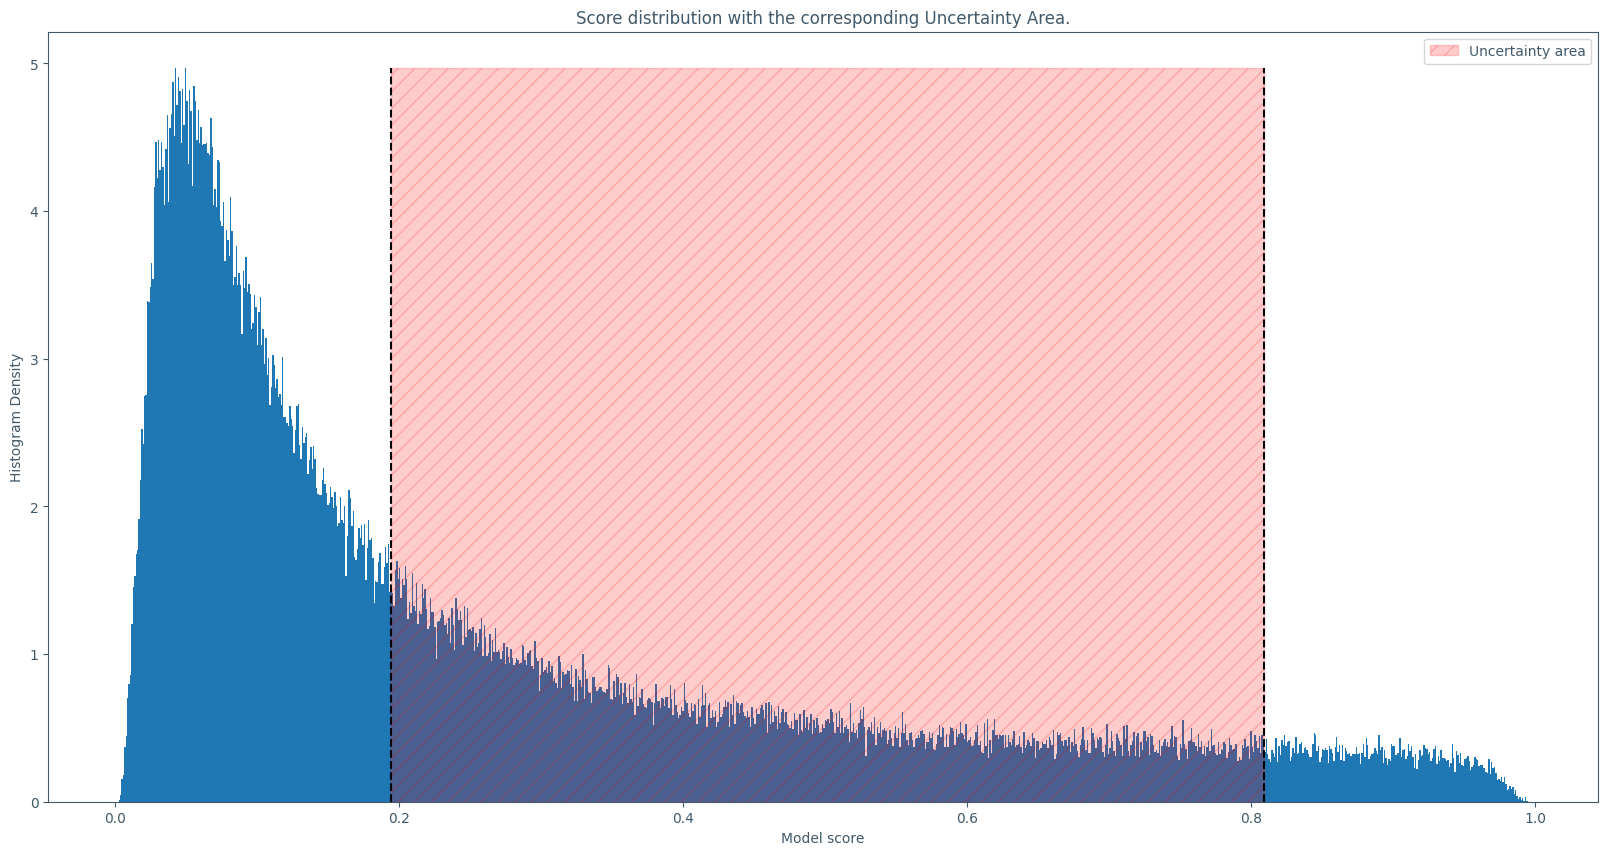

In [35]:
mapie_clf = conformal_predictions.train_conformal_predictor()